#### Tyre Degradation
###### 1.This notebooks contains the code for dataset creation for Tyre Degradation.
###### 2.Plotting degradation curves
###### 3. Testing Linear Vs Non-linear behaviour

In [2]:
import pandas as pd 
driver_df = pd.read_csv("C:/Users/VANSH/Formula1/datasets/2024/raw_driver_2024.csv")

In [9]:
def time_to_seconds(x):

    if pd.isna(x):
        return None

    try:
        return pd.to_timedelta(x).total_seconds()

    except:
        return None

In [10]:
def clean_driver_data_degrad(driver_df):

    # Make copy
    cleaned_df = driver_df.copy()

    # -------------------------
    # Convert time columns
    # -------------------------

    time_cols = [
        'LapTime',
        'Sector1Time',
        'Sector2Time',
        'Sector3Time'
    ]

    for col in time_cols:

        cleaned_df[col] = cleaned_df[col].apply(
            time_to_seconds
        )

    # -------------------------
    # Drop missing LapTime/Compound
    # -------------------------

    before_drop = cleaned_df.shape[0]

    cleaned_df = cleaned_df.dropna(
        subset=['LapTime', 'Compound']
    )

    print(
        f"Dropped {before_drop - cleaned_df.shape[0]} rows "
        f"with missing LapTime/Compound"
    )

    # -------------------------
    # Handle TyreLife
    # -------------------------

    missing_tyre = cleaned_df['TyreLife'].isna().sum()

    cleaned_df['TyreLife'] = (
        cleaned_df['TyreLife']
        .fillna(0)
        .astype(int)
    )

    print(
        f"Filled {missing_tyre} missing TyreLife values with 0"
    )

    # -------------------------
    # Handle FreshTyre
    # -------------------------

    missing_fresh = cleaned_df['FreshTyre'].isna().sum()

    cleaned_df['FreshTyre'] = (
        cleaned_df['FreshTyre']
        .fillna(False)
        .astype(int)
    )

    print(
        f"Filled {missing_fresh} missing FreshTyre values with False"
    )

    # -------------------------
    # Preserve degradation columns
    # -------------------------

    degradation_cols = [
        'TrackStatus',
        'PitInTime',
        'PitOutTime',
        'Deleted',
        'DeletedReason',
        'IsAccurate'
    ]

    existing_cols = [
        col for col in degradation_cols
        if col in cleaned_df.columns
    ]

    print(
        f"Preserved degradation columns: "
        f"{existing_cols}"
    )

    # -------------------------
    # Reset index
    # -------------------------

    cleaned_df = cleaned_df.reset_index(
        drop=True
    )
    cleaned_df.to_csv(
    "C:/Users/VANSH/Formula1/datasets/2024/degrad_cleaned_driver_2024.csv", index=False)
    print("Cleaned driver data saved to 'degrad_cleaned_driver_2024.csv'")
    return cleaned_df
    

In [11]:
cleaned_driver_df = clean_driver_data_degrad(driver_df)

Dropped 8260 rows with missing LapTime/Compound
Filled 14 missing TyreLife values with 0
Filled 0 missing FreshTyre values with False
Preserved degradation columns: ['TrackStatus', 'PitInTime', 'PitOutTime', 'Deleted', 'DeletedReason', 'IsAccurate']
Cleaned driver data saved to 'degrad_cleaned_driver_2024.csv'


['Time',
 'Driver',
 'DriverNumber',
 'LapTime',
 'LapNumber',
 'Stint',
 'PitOutTime',
 'PitInTime',
 'Sector1Time',
 'Sector2Time',
 'Sector3Time',
 'Sector1SessionTime',
 'Sector2SessionTime',
 'Sector3SessionTime',
 'SpeedI1',
 'SpeedI2',
 'SpeedFL',
 'SpeedST',
 'IsPersonalBest',
 'Compound',
 'TyreLife',
 'FreshTyre',
 'Team',
 'LapStartTime',
 'LapStartDate',
 'TrackStatus',
 'Position',
 'Deleted',
 'DeletedReason',
 'FastF1Generated',
 'IsAccurate',
 'RoundNumber',
 'GP',
 'Session',
 'Date']

In [15]:
import pandas as pd

# Load cleaned degradation dataset
df = pd.read_csv(
    "C:/Users/VANSH/Formula1/datasets/2024/degrad_cleaned_driver_2024.csv"
)

print("Before filtering:", len(df))

# Race laps only
degradation_df = df[
    df["Session"] == "R"
].copy()

# Accurate laps only
degradation_df = degradation_df[
    degradation_df["IsAccurate"] == True
]

# Remove deleted laps
degradation_df = degradation_df[
    degradation_df["Deleted"] == False
]

# Remove pit-in laps
degradation_df = degradation_df[
    degradation_df["PitInTime"].isna()
]

# Remove pit-out laps
degradation_df = degradation_df[
    degradation_df["PitOutTime"].isna()
]

# Green flag laps only
degradation_df = degradation_df[
    degradation_df["TrackStatus"].astype(str) == "1"
]

print("After filtering:", len(degradation_df))
print("Removed:", len(df) - len(degradation_df))

degradation_df.to_csv(
    "degradation_dataset_2024_v1.csv",
    index=False
)

print("Saved: degradation_dataset_2024_v1.csv")

Before filtering: 52010
After filtering: 22719
Removed: 29291
Saved: degradation_dataset_2024_v1.csv


#### Plotting 

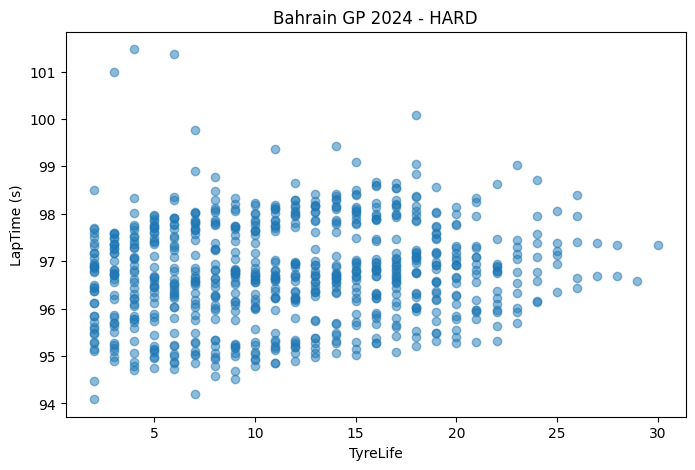

Rows plotted: 719


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

sample = df[
    (df["GP"] == "Bahrain Grand Prix") &
    (df["Compound"] == "HARD")
].copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    sample["TyreLife"],
    sample["LapTime"],
    alpha=0.5
)

plt.xlabel("TyreLife")
plt.ylabel("LapTime (s)")
plt.title("Bahrain GP 2024 - HARD")

plt.show()

print("Rows plotted:", len(sample))

##### Bahrain GP Verstappen Hard Compound

Stint
2.0    18
dtype: int64


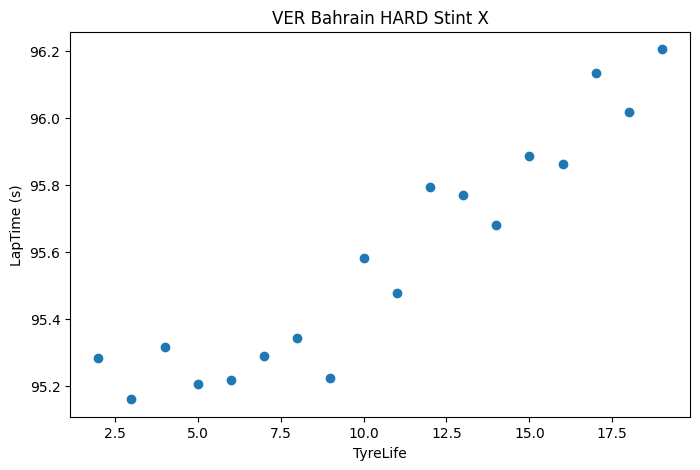

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

sample = df[
    (df["GP"] == "Bahrain Grand Prix") &
    (df["Driver"] == "VER") &
    (df["Compound"] == "HARD")
]

print(
    sample.groupby("Stint")
    .size()
    .sort_values(ascending=False)
)


stint_df = sample[
    sample["Stint"] == 2  # replace X
]

plt.figure(figsize=(8,5))

plt.scatter(
    stint_df["TyreLife"],
    stint_df["LapTime"]
)

plt.xlabel("TyreLife")
plt.ylabel("LapTime (s)")
plt.title(
    "VER Bahrain HARD Stint X"
)

plt.show()

##### Bahrain GP VER Medium Compound

Stint
3.0    18
1.0    13
dtype: int64


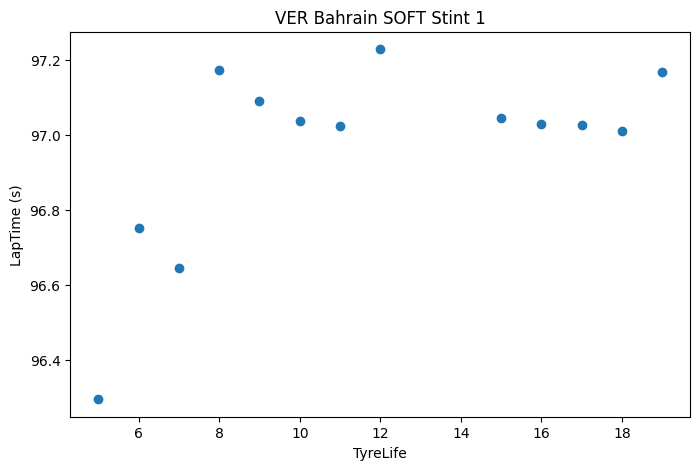

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

sample = df[
    (df["GP"] == "Bahrain Grand Prix") &
    (df["Driver"] == "VER") &
    (df["Compound"] == "SOFT")
]

print(
    sample.groupby("Stint")
    .size()
    .sort_values(ascending=False)
)


stint_df = sample[
    sample["Stint"] == 1  # replace X
]

plt.figure(figsize=(8,5))

plt.scatter(
    stint_df["TyreLife"],
    stint_df["LapTime"]
)

plt.xlabel("TyreLife")
plt.ylabel("LapTime (s)")
plt.title(
    "VER Bahrain SOFT Stint 1"
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("degradation_dataset_2024_v1.csv")

def plot_longest_stint(gp, compound):

    sample = df[
        (df["GP"] == gp) &
        (df["Compound"] == compound)
    ]

    stint_lengths = (
        sample.groupby(
            ["Driver", "Stint"]
        )
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )
    

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]
    best_laps = stint_lengths.iloc[0]["Laps"]

    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ]

    plt.figure(figsize=(8,5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["LapTime"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("LapTime (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint} "
        f"({best_laps} laps)"
    )

    plt.show()

    print(
        f"Driver: {best_driver}, "
        f"Stint: {best_stint}, "
        f"Laps: {best_laps}"
    )
    if sample.empty:
        print(f"No data found for {gp} - {compound}")
    return

Compound
HARD    719
SOFT    269
Name: count, dtype: int64


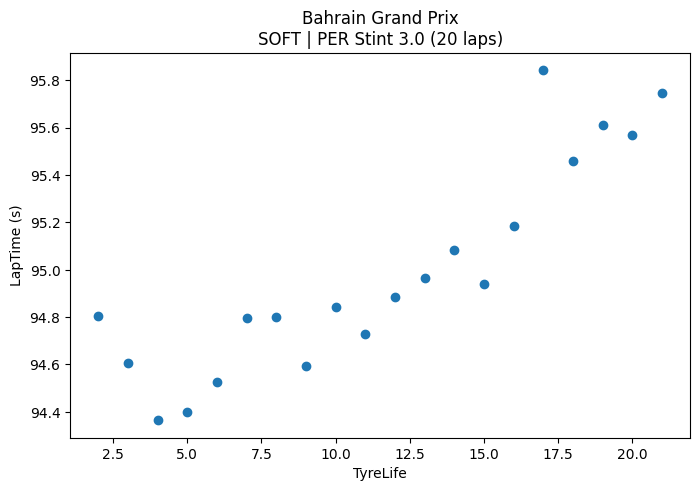

Driver: PER, Stint: 3.0, Laps: 20


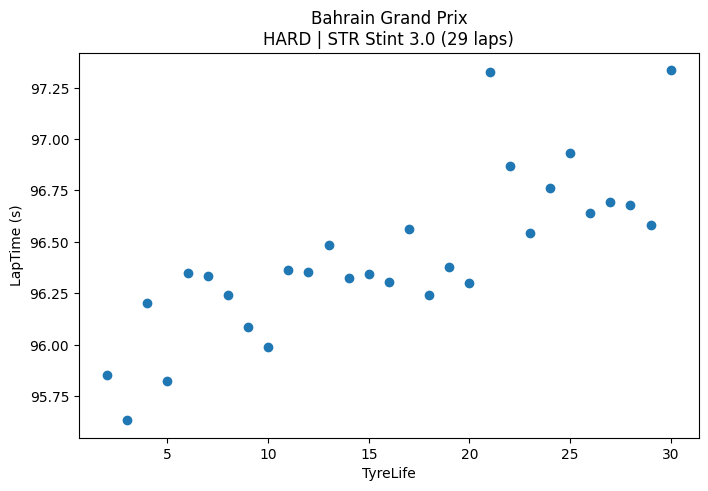

Driver: STR, Stint: 3.0, Laps: 29


IndexError: single positional indexer is out-of-bounds

In [31]:
plot_longest_stint(
    "Bahrain Grand Prix",
    "SOFT"
)

plot_longest_stint(
    "Bahrain Grand Prix",
    "HARD"
)

plot_longest_stint(
    "Bahrain Grand Prix",
    "MEDIUM"
)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("degradation_dataset_2024_v1.csv")

def plot_longest_stint(gp, compound):

    sample = df[
        (df["GP"] == gp) &
        (df["Compound"] == compound)
    ]

    stint_lengths = (
        sample.groupby(
            ["Driver", "Stint"]
        )
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )
    

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]
    best_laps = stint_lengths.iloc[0]["Laps"]

    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ]

    plt.figure(figsize=(8,5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["LapTime"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("LapTime (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint} "
        f"({best_laps} laps)"
    )

    plt.show()

    print(
        f"Driver: {best_driver}, "
        f"Stint: {best_stint}, "
        f"Laps: {best_laps}"
    )
    if sample.empty:
        print(f"No data found for {gp} - {compound}")
    return

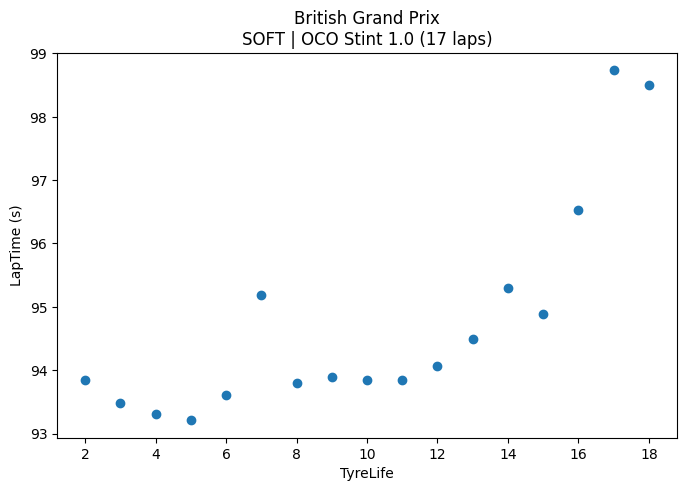

Driver: OCO, Stint: 1.0, Laps: 17


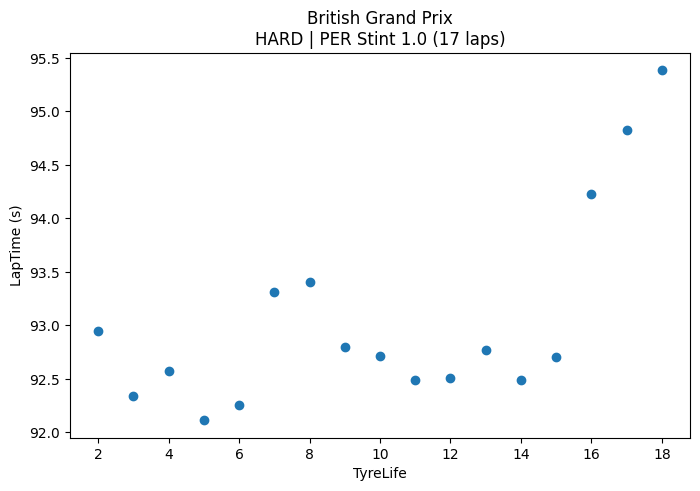

Driver: PER, Stint: 1.0, Laps: 17


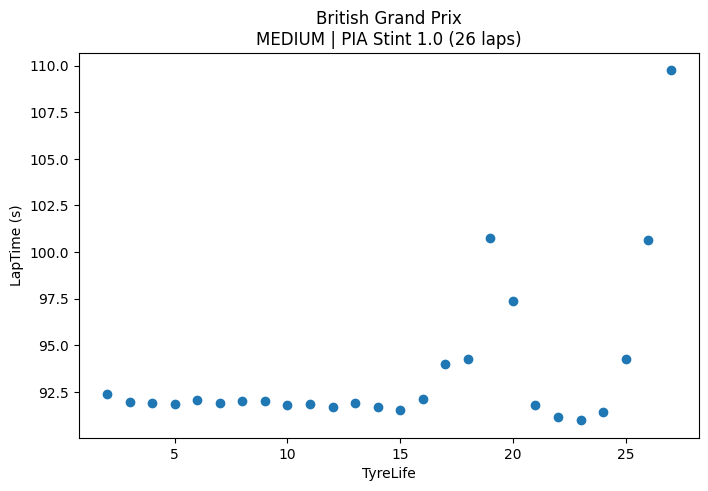

Driver: PIA, Stint: 1.0, Laps: 26


In [2]:
plot_longest_stint(
    "British Grand Prix",
    "SOFT"
)

plot_longest_stint(
    "British Grand Prix",
    "HARD"
)

plot_longest_stint(
    "British Grand Prix",
    "MEDIUM"
)

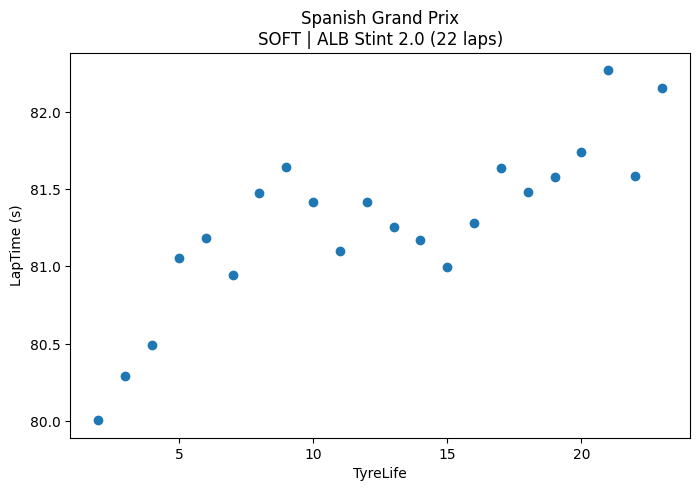

Driver: ALB, Stint: 2.0, Laps: 22


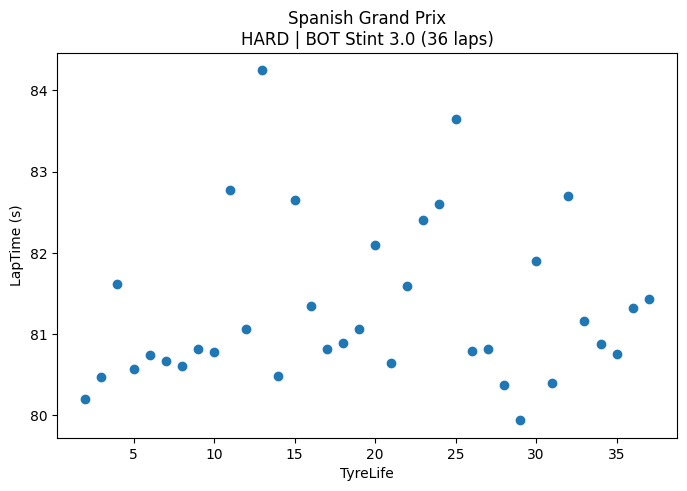

Driver: BOT, Stint: 3.0, Laps: 36


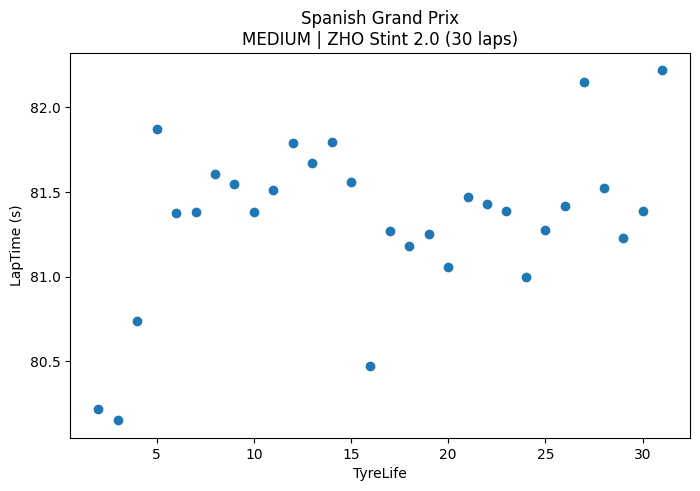

Driver: ZHO, Stint: 2.0, Laps: 30


In [3]:
plot_longest_stint(
    "Spanish Grand Prix",
    "SOFT"
)

plot_longest_stint(
    "Spanish Grand Prix",
    "HARD"
)

plot_longest_stint(
    "Spanish Grand Prix",
    "MEDIUM"
)

In [4]:
import pandas as pd

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

# Best lap of each stint
df["BestLapInStint"] = (
    df.groupby(
        ["GP", "Driver", "Stint"]
    )["LapTime"]
    .transform("min")
)

# Tyre performance loss
df["TyreDelta"] = (
    df["LapTime"]
    - df["BestLapInStint"]
)

print(
    df[
        ["LapTime",
         "BestLapInStint",
         "TyreDelta"]
    ].head()
)

   LapTime  BestLapInStint  TyreDelta
0   96.296          96.296      0.000
1   96.753          96.296      0.457
2   96.647          96.296      0.351
3   97.173          96.296      0.877
4   97.092          96.296      0.796


In [5]:
import matplotlib.pyplot as plt

def plot_longest_stint_delta(gp, compound):

    sample = df[
        (df["GP"] == gp) &
        (df["Compound"] == compound)
    ]

    stint_lengths = (
        sample.groupby(
            ["Driver", "Stint"]
        )
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )

    if stint_lengths.empty:
        print("No data found")
        return

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]

    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ]

    plt.figure(figsize=(8,5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["TyreDelta"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("TyreDelta (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint}"
    )

    plt.show()

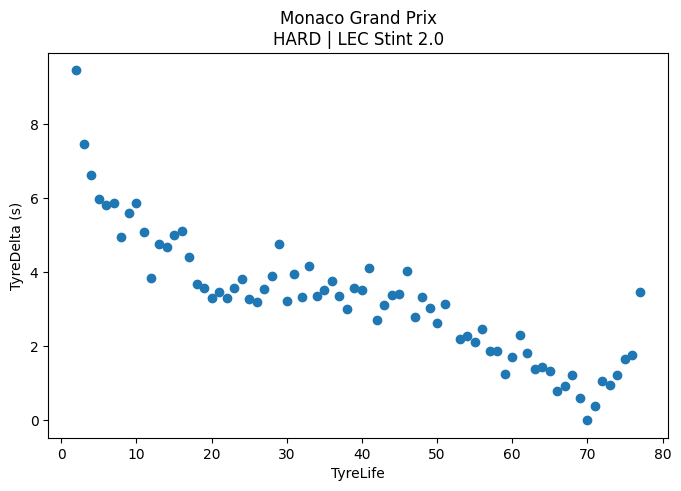

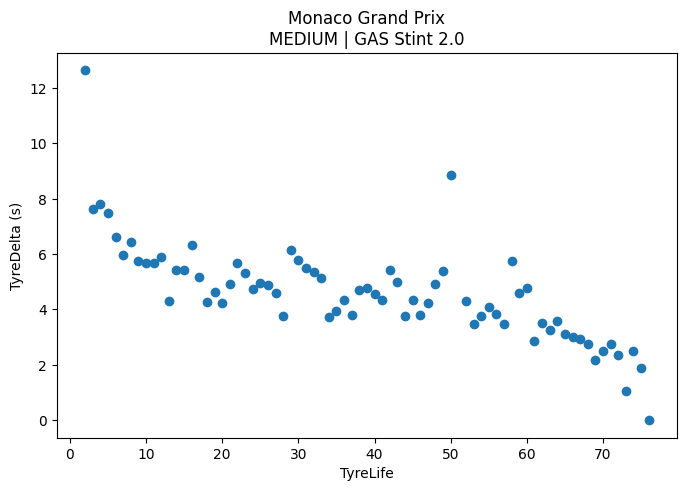

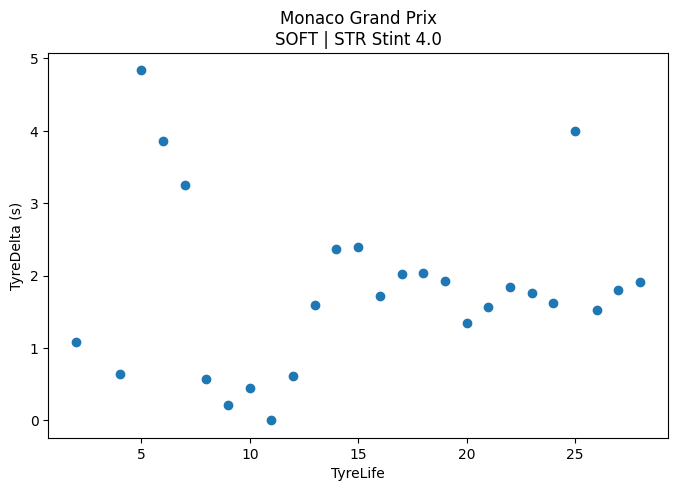

In [6]:
plot_longest_stint_delta(
    "Monaco Grand Prix",
    "HARD"
)

plot_longest_stint_delta(
    "Monaco Grand Prix",
    "MEDIUM"
)

plot_longest_stint_delta(
    "Monaco Grand Prix",
    "SOFT"
)